# Notebook 02 — Closed-Form Approximations vs Exact ODE

**Figures reproduced**: 
- 2–5 (IG index, $\sigma$ (normal),Bid, ask, spread, skew — exact (×) vs approx (—)), 
- 6-7 (IG index, $\sigma / 2$, Same but approx improves dramatically)
- 10–14 (HY index, $\sigma$ (normal), Same overlay for HY)



In Notebook 01 we solved the **exact ODE** (Eq. 3.9) numerically and plotted the optimal quotes.
This notebook asks: *can we get those quotes in closed form, without solving any ODE?*


## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

import sys
sys.path.append(str(Path().resolve().parents[0]))

from asset.params import IG, HY, GAMMA, T
from src.ode_solver_1d import solve_general
from src.closed_form import approx_quotes, approx_spread, approx_skew
from src.intensity import C_coeff

plt.style.use("seaborn-v0_8")
%matplotlib inline

## 0. The closed-form approximation 

In the asymptotic regime ($t \ll T$), the solution simplifies to:

$$\delta^{b*}_{\text{approx}}(n) = \delta_{\text{static}} + \omega \cdot \frac{(2n+1)\Delta}{2}$$
$$\delta^{a*}_{\text{approx}}(n) = \delta_{\text{static}} - \omega \cdot \frac{(2n-1)\Delta}{2}$$

where:

| Symbol | Formula | Role |
|--------|---------|------|
| $\delta_{\text{static}}$ | $\frac{1}{\xi\Delta}\ln\!\left(1 + \frac{\xi\Delta}{k}\right)$ | **Static half-spread** — the quote when inventory doesn't matter |
| $\omega$ | $\sqrt{\dfrac{\gamma\sigma^2}{2\,H''_\xi(0)}} = \sqrt{\dfrac{\gamma\sigma^2}{2\,A\Delta k\,C_\xi}}$ | **Dynamic slope** — how fast quotes tilt with inventory |

And:

$$\text{Spread}_{\text{approx}} = \delta^b + \delta^a = 2\,\delta_{\text{static}} + \omega\Delta \qquad \text{(constant in } n \text{)}$$
$$\text{Skew}_{\text{approx}} = \delta^b - \delta^a = 2n \cdot \omega\Delta \qquad \text{(linear in } n \text{)}$$

## 3. Parameters and intermediate quantities

We use the same IG / HY parameters as Notebook 01 (Paper §6, p. 31), plus a variant with $\sigma_{\text{IG}} / 2$.

The closed-form formulas depend on two intermediate quantities ($\delta_{\text{static}}$ and $\omega$), so let's compute and inspect them explicitly.


In [2]:
# ── Build the three parameter sets ──
IG_half = {**IG, "sigma": IG["sigma"] / 2}  # Paper Figs 6–7

configs = [
    ("IG (σ)",   IG),
    ("IG (σ/2)", IG_half),
    ("HY (σ)",   HY),
]

print(f"{'Config':<12s}  {'σ':>12s}  {'ξΔ':>8s}  {'δ_static':>12s}  {'ω':>12s}  "
      f"{'Spread_cf':>12s}  {'Skew(n=3)_cf':>14s}")
print("─" * 92)

for label, p in configs:
    xi_Delta = GAMMA * p["Delta"]
    
    # δ_static  (Eq. 4.6 / 4.7 — the constant term)
    d_static = (1.0 / xi_Delta) * np.log(1.0 + xi_Delta / p["k"])
    
    # ω  (Eq. 4.3 applied to exponential case)
    C = C_coeff(xi_Delta, p["k"])
    omega = np.sqrt(GAMMA * p["sigma"]**2 / (2.0 * p["A"] * p["Delta"] * p["k"] * C))
    
    # Spread and skew from Eqs. 4.8–4.9
    spread = 2 * d_static + omega * p["Delta"]
    skew_3 = 2 * 3 * omega * p["Delta"]
    
    print(f"{label:<12s}  {p['sigma']:>12.2e}  {xi_Delta:>8.0f}  {d_static:>12.6e}  {omega:>12.6e}  "
          f"{spread:>12.6e}  {skew_3:>14.6e}")


Config                   σ        ξΔ      δ_static             ω     Spread_cf    Skew(n=3)_cf
────────────────────────────────────────────────────────────────────────────────────────────
IG (σ)            5.83e-06      3000  5.164948e-05  1.919561e-12  1.992770e-04    5.758682e-04
IG (σ/2)          2.92e-06      3000  5.164948e-05  9.597803e-13  1.512880e-04    2.879341e-04
HY (σ)            2.15e-05       600  1.734666e-04  2.618159e-11  6.087492e-04    1.570896e-03


## 5. Solve exact ODE (Eq. 3.9, Model A)

We need the exact solution as the reference against which to compare the closed-form formulas. Same solver as Notebook 01 (`solve_general`, Newton on implicit Euler, $N_t = 7200$).


In [6]:
N_T = 7200

# Solving IG — Model A (σ normal) 
#Done in 3.3s
t0 = time.time()
sol_ig = solve_general(IG, GAMMA, T, xi=GAMMA, N_t=N_T)

In [7]:
# Solving IG — Model A (σ/2)
t0 = time.time()
sol_ig_half = solve_general(IG_half, GAMMA, T, xi=GAMMA, N_t=N_T)

In [8]:
# Solving HY — Model A (σ normal)
t0 = time.time()
sol_hy = solve_general(HY, GAMMA, T, xi=GAMMA, N_t=N_T)

## 6. Quantitative comparison: approximation error

Before plotting, let's measure the error numerically. This quantifies the paper's qualitative statements about when the approximation is *"satisfactory"* vs *"more questionable"* (p. 33).


In [15]:
def error_report(sol, params, label):
    """Compute max/mean absolute and relative errors between exact and approx."""
    Q = int(params["Q"])
    n_arr = np.arange(-Q + 1, Q)
    
    db_cf, da_cf = approx_quotes(n_arr, params, GAMMA, xi=GAMMA)
    
    # Exact values at t=0, restricted to the same n range
    # n_arr maps to indices [1, ..., 2Q-1] in the lots array
    idx = np.array([int(n + Q) for n in n_arr])
    db_ex = sol["delta_bid"][0, idx]
    da_ex = sol["delta_ask"][0, idx]
    
    # Filter out NaNs (boundaries)
    mask_b = np.isfinite(db_ex)
    mask_a = np.isfinite(da_ex)
    
    for side, ex, cf, mask in [("Bid", db_ex, db_cf, mask_b), ("Ask", da_ex, da_cf, mask_a)]:
        abs_err = np.abs(ex[mask] - cf[mask])
        rel_err = abs_err / np.abs(ex[mask])
        print(f"  {label} {side}:  max|err| = {abs_err.max():.3e}  "
              f" mean|err| = {abs_err.mean():.3e}  "
              #f" max rel = {rel_err.max():.1%}  "
              #f" mean rel = {rel_err.mean():.1%}"
              )

print("─" * 70)
error_report(sol_ig, IG, "IG (σ)  ")
print("─" * 70)
error_report(sol_ig_half, IG_half, "IG (σ/2)")
print("─" * 70)
error_report(sol_hy, HY, "HY (σ)  ")
print("─" * 70)

──────────────────────────────────────────────────────────────────────
  IG (σ)   Bid:  max|err| = 1.199e-04   mean|err| = 4.007e-05  
  IG (σ)   Ask:  max|err| = 1.199e-04   mean|err| = 4.007e-05  
──────────────────────────────────────────────────────────────────────
  IG (σ/2) Bid:  max|err| = 2.480e-05   mean|err| = 8.101e-06  
  IG (σ/2) Ask:  max|err| = 2.480e-05   mean|err| = 8.101e-06  
──────────────────────────────────────────────────────────────────────
  HY (σ)   Bid:  max|err| = 2.741e-04   mean|err| = 8.800e-05  
  HY (σ)   Ask:  max|err| = 2.741e-04   mean|err| = 8.800e-05  
──────────────────────────────────────────────────────────────────────


Expected: σ/2 errors << σ errors 

## 7. Figures 2–5 (IG, $\sigma$ normal) — Exact vs Closed-Form

**Paper reference** (p. 32–33):
- **Fig 2**: $q_{\text{IG}} \mapsto \delta^{b,*}(0, q_{\text{IG}})$ — crosses (exact) + line (Eq. 4.6)
- **Fig 3**: $q_{\text{IG}} \mapsto \delta^{a,*}(0, q_{\text{IG}})$ — crosses (exact) + line (Eq. 4.7)
- **Fig 4**: Spread — crosses (exact) + line (Eq. 4.8)
- **Fig 5**: Skew — crosses (exact) + line (Eq. 4.9)

> *"The closed-form approximations are satisfactory for small values of the inventory (in absolute value), but more questionable for larger values. In particular, the optimal quotes are not affine functions of the inventory."* — p. 33


In [16]:

def overlay_plots(sol, params, label, sigma_label,
                  fig_bid=None, fig_ask=None, fig_spread=None, fig_skew=None):
    """Plot exact (markers) vs closed-form (line) for bid, ask, spread, skew.
    
    Parameters
    ----------
    sol         : dict from solve_general
    params      : parameter dict (sigma, A, k, Delta, Q)
    label       : "IG" or "HY"
    sigma_label : "σ" or "σ/2" -- used in titles
    fig_*       : paper figure numbers (optional, for title annotation)
    """
    lots = sol["lots"]
    Q = int(params["Q"])

    # ── Closed-form approximation (Eqs. 4.6–4.7) ──
    n_arr = np.arange(-Q + 1, Q)  # n = -3,...,+3 for Q=4
    db_cf, da_cf = approx_quotes(n_arr, params, GAMMA, xi=GAMMA)
    spread_cf = db_cf + da_cf     # Eq. 4.8: should be constant
    skew_cf = db_cf - da_cf       # Eq. 4.9: should be linear

    # ── Exact ODE at t=0 (asymptotic regime) ──
    db_exact = sol["delta_bid"][0, :]
    da_exact = sol["delta_ask"][0, :]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ── Top-left: Bid (Paper Fig 2/6/11) ──
    ax = axes[0, 0]
    mask = np.isfinite(db_exact)
    ax.plot(lots[mask], db_exact[mask], "x", ms=9, label="Exact (ODE, Eq. 3.9)",
            color="C0", zorder=3)
    ax.plot(n_arr, db_cf, "-", lw=2, label="Approx (Eq. 4.6)", color="C1")
    title = f"{label} ({sigma_label}) — δ^bid(0, n)"
    if fig_bid: title = f"Fig {fig_bid}: " + title
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^bid ($/upfront)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── Top-right: Ask (Paper Fig 3/7/12) ──
    ax = axes[0, 1]
    mask = np.isfinite(da_exact)
    ax.plot(lots[mask], da_exact[mask], "o", ms=9, label="Exact (ODE, Eq. 3.9)",
            color="C0", zorder=3)
    ax.plot(n_arr, da_cf, "-", lw=2, label="Approx (Eq. 4.7)", color="C1")
    title = f"{label} ({sigma_label}) — δ^ask(0, n)"
    if fig_ask: title = f"Fig {fig_ask}: " + title
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^ask ($/upfront)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── Bottom-left: Spread (Paper Fig 4/13) ──
    ax = axes[1, 0]
    spread_exact = db_exact + da_exact
    mask = np.isfinite(spread_exact)
    ax.plot(lots[mask], spread_exact[mask], "s", ms=9, label="Exact", color="C0", zorder=3)
    ax.plot(n_arr, spread_cf, "-", lw=2, label="Approx (Eq. 4.8 → constant)", color="C1")
    title = f"{label} ({sigma_label}) — Spread(0, n)"
    if fig_spread: title = f"Fig {fig_spread}: " + title
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^b + δ^a ($/upfront)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── Bottom-right: Skew (Paper Fig 5/14) ──
    ax = axes[1, 1]
    skew_exact = db_exact - da_exact
    mask = np.isfinite(skew_exact)
    ax.plot(lots[mask], skew_exact[mask], "D", ms=9, label="Exact", color="C0", zorder=3)
    ax.plot(n_arr, skew_cf, "-", lw=2, label="Approx (Eq. 4.9 → linear)", color="C1")
    title = f"{label} ({sigma_label}) — Skew(0, n)"
    if fig_skew: title = f"Fig {fig_skew}: " + title
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^b − δ^a ($/upfront)")
    ax.axhline(0, color="gray", ls=":", lw=0.8)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    fig.suptitle(f"Closed-form (§4) vs exact ODE (§3) — {label} ({sigma_label})",
                 fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()


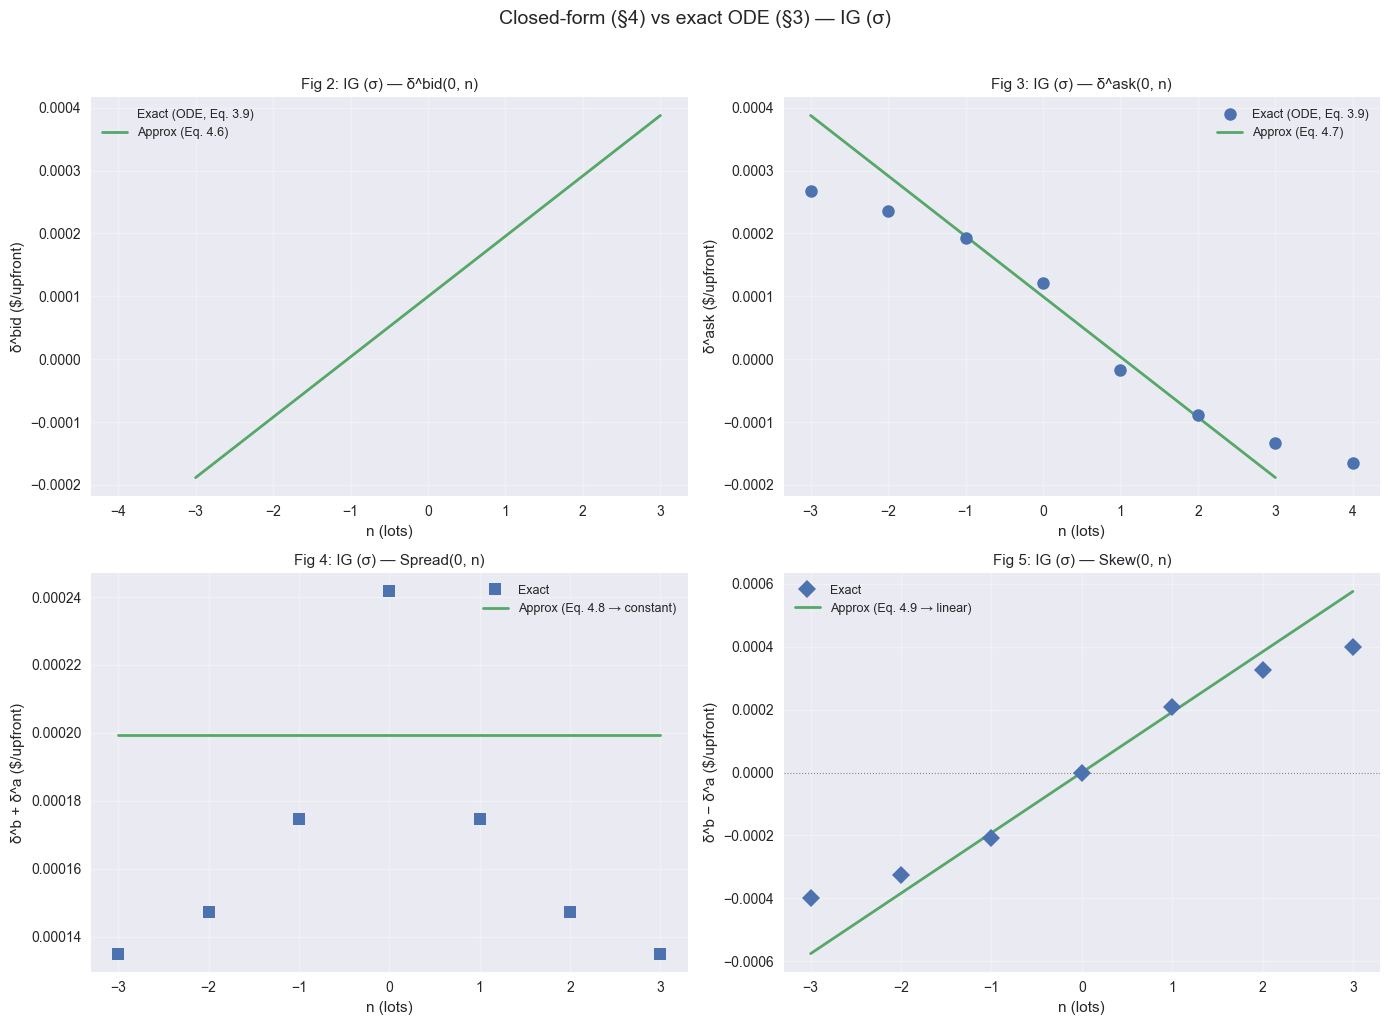

In [17]:
overlay_plots(sol_ig, IG, "IG", "σ", fig_bid=2, fig_ask=3, fig_spread=4, fig_skew=5)


## 8. Figures 6–7 (IG, $\sigma / 2$) — Approximation improves at low volatility

**Paper reference** (p. 34):
> *"If we consider market conditions with less volatility, then the closed-form approximations are far better — see Figures 6 and 7 where we computed the optimal bid and ask quotes (in Model A) for a value of $\sigma_{\text{IG}}$ divided by 2."*

**Why does halving $\sigma$ help?**

The dynamic slope $\omega \propto \sigma$, so halving $\sigma$ halves $\omega$. This means:
- The inventory-dependent part of the quote ($\omega \cdot n \cdot \Delta$) becomes smaller.
- $\theta(t, q)$ is flatter → the Taylor expansion (which assumed $\Delta$ is "small") becomes more accurate.
- Effectively, the ratio of the inventory penalty ($\frac{1}{2}\gamma\sigma^2 q^2$) to the fill benefit ($H_\xi$) shrinks, bringing us closer to the regime where the continuous PDE approximation is valid.

The paper only shows Figs 6–7 (bid + ask); we include spread and skew as well.


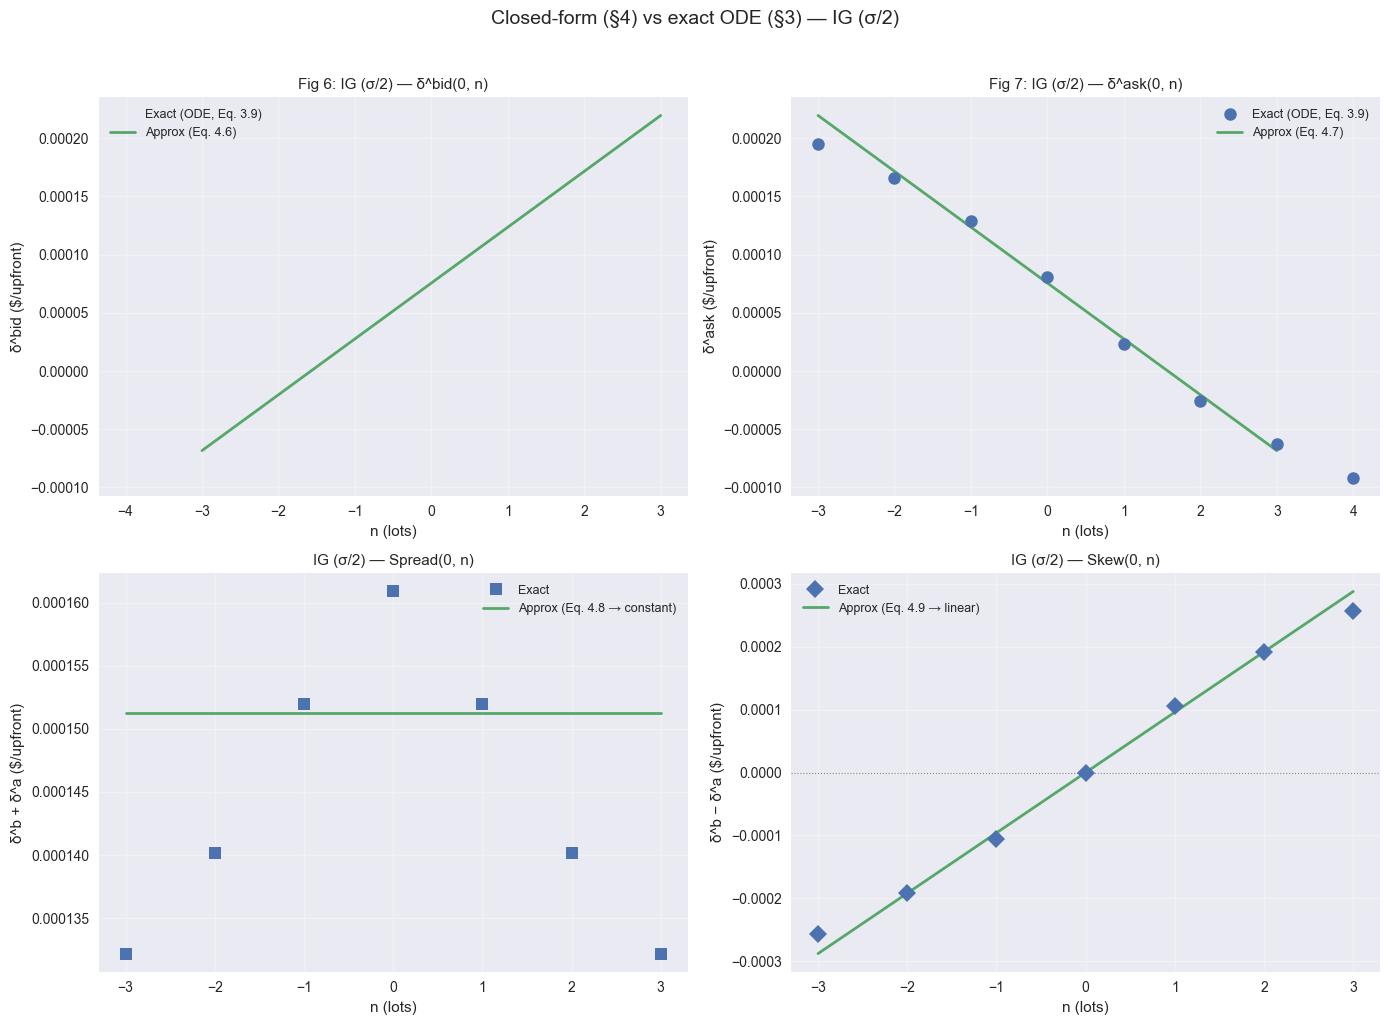

In [18]:
overlay_plots(sol_ig_half, IG_half, "IG", "σ/2", fig_bid=6, fig_ask=7)

## 9. Figures 11–14 (HY, $\sigma$ normal) — Same analysis for the HY index

**Paper reference** (p. 37):
> *"We also see that the closed-form approximations are satisfactory only for small values of the inventory (in absolute value)."*

The HY index has:
- **Higher $\sigma$** ($2.15 \times 10^{-5}$ vs $5.83 \times 10^{-6}$) → stronger inventory penalty.
- **Smaller $\Delta$** ($10$M vs $50$M) → smaller ξΔ = 600 (vs 3000 for IG).
- **Smaller $k$** ($5.47 \times 10^3$ vs $1.79 \times 10^4$) → fills less sensitive to spread.

The net effect: $\omega_{\text{HY}} \gg \omega_{\text{IG}}$ (we can verify below), so the approximation error should be larger for HY.


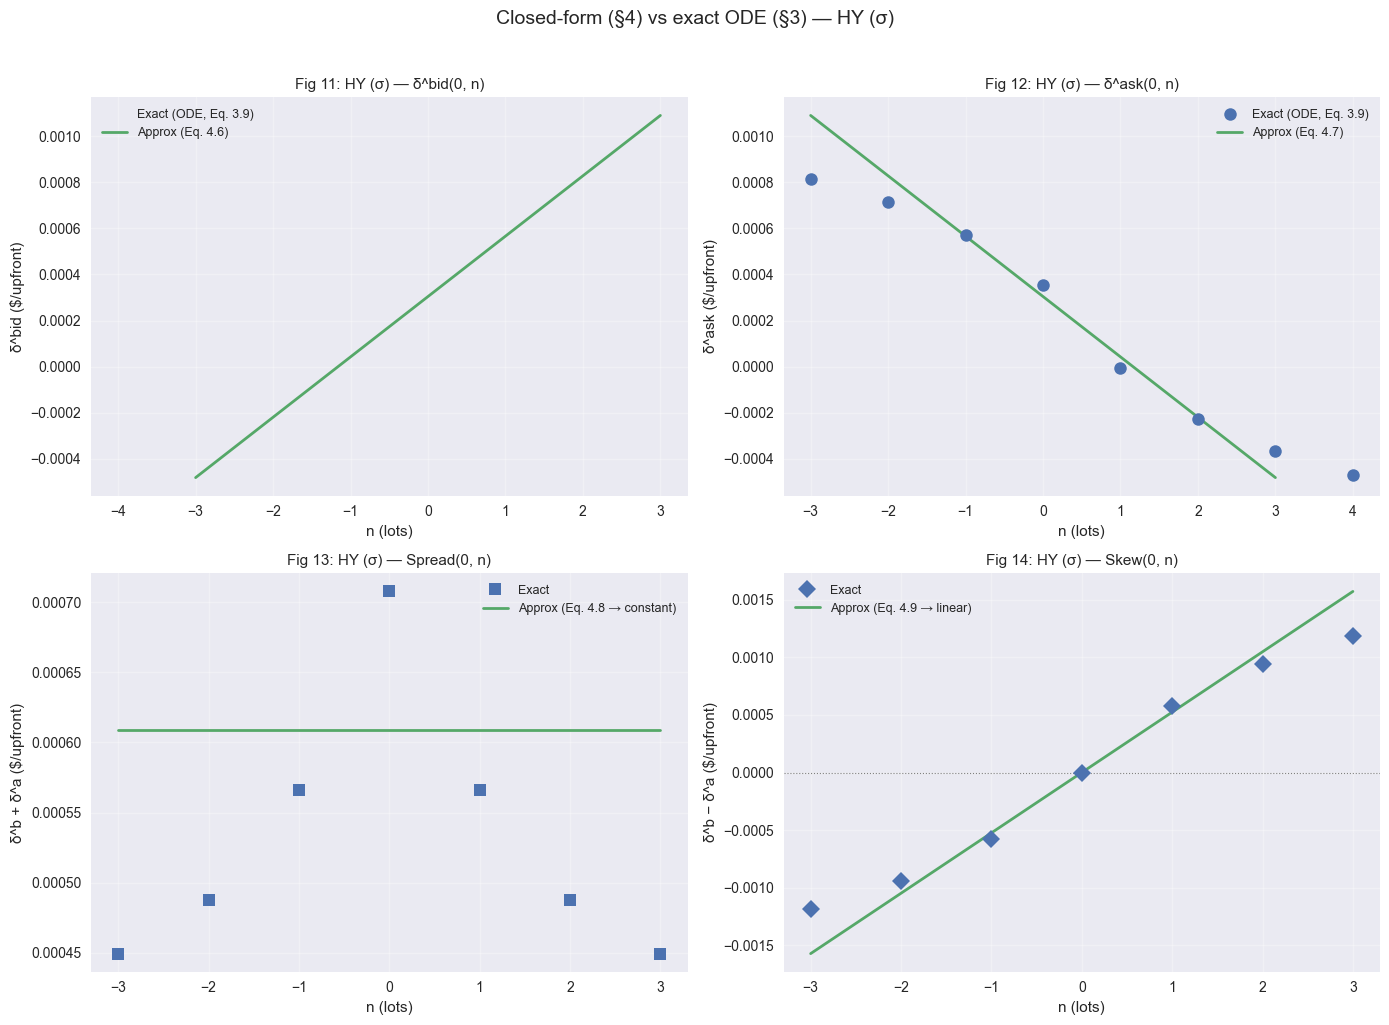

In [19]:
overlay_plots(sol_hy, HY, "HY", "σ", fig_bid=11, fig_ask=12, fig_spread=13, fig_skew=14)

## 10. Bonus: Decomposing the spread into static and dynamic components

The closed-form spread (Eq. 4.8) has two parts:

$$\text{Spread} = \underbrace{2\,\delta_{\text{static}}}_{\text{compensation for adverse selection}} + \underbrace{\omega \cdot \Delta}_{\text{compensation for inventory risk}}$$

Let's visualise the relative weight of each component.


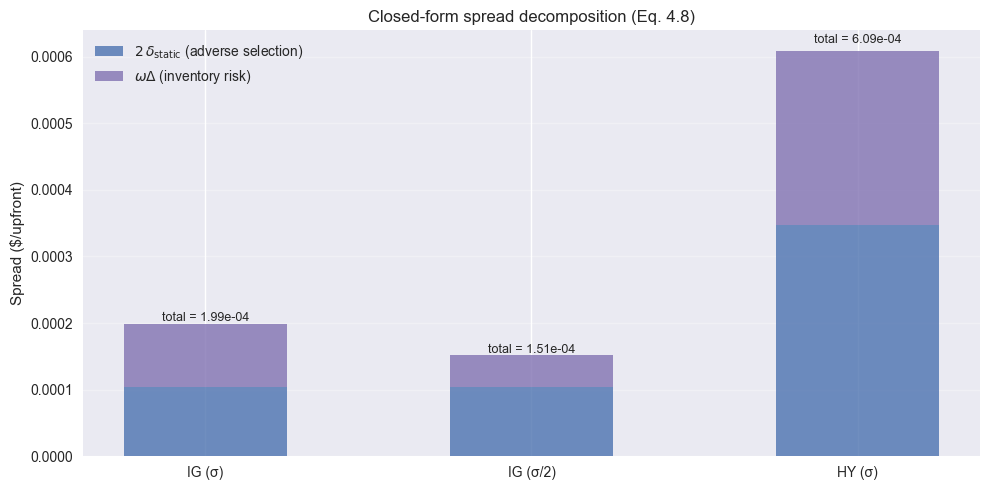

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

bar_data = []
for label, p in [("IG (σ)", IG), ("IG (σ/2)", IG_half), ("HY (σ)", HY)]:
    xi_Delta = GAMMA * p["Delta"]
    d_static = (1.0 / xi_Delta) * np.log(1.0 + xi_Delta / p["k"])
    C = C_coeff(xi_Delta, p["k"])
    omega = np.sqrt(GAMMA * p["sigma"]**2 / (2.0 * p["A"] * p["Delta"] * p["k"] * C))
    
    static_part = 2 * d_static
    dynamic_part = omega * p["Delta"]
    bar_data.append((label, static_part, dynamic_part))

labels = [d[0] for d in bar_data]
statics = [d[1] for d in bar_data]
dynamics = [d[2] for d in bar_data]

x = np.arange(len(labels))
w = 0.5
ax.bar(x, statics, w, label=r"$2\,\delta_{\mathrm{static}}$ (adverse selection)", color="C0", alpha=0.8)
ax.bar(x, dynamics, w, bottom=statics, label=r"$\omega\Delta$ (inventory risk)", color="C3", alpha=0.8)

for i, (s, d) in enumerate(zip(statics, dynamics)):
    ax.text(i, s + d + (s+d)*0.02, f"total = {s+d:.2e}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Spread ($/upfront)")
ax.set_title("Closed-form spread decomposition (Eq. 4.8)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()
